In [3]:
from langgraph.graph import StateGraph  , START , END 
from typing import TypedDict , Literal , Dict , Optional , Annotated
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langgraph.graph.message import BaseMessage , add_messages



In [4]:
class OrderState(TypedDict):
    data :  Dict
    user_order : str
    total_items : int
    
    is_stock : Optional[str]
    amount :  float
    amount_with_tax : float
    messages : Annotated[list[BaseMessage], add_messages]
    


In [5]:
def check_have_stock(state : OrderState):
    order = state['user_order']
    data  = state['data']
    if order in data and data[order][0] >= state['total_items']:
        return {"is_stock" : "Yes"}
    else:
        return{"in_stock" : "No"}

def out_of_stock(state : OrderState):
    print(f"Sorry item :{state['user_order']} is currently not in stock")

def in_stock(state : OrderState):
    # calculating total price 
    order = state['user_order']
    data  = state['data']
    quantity = state['total_items']
    amount = data.get(order)[1] * quantity
    
    return {"amount" : amount}

def apply_gst(state : OrderState):
    amount = state['amount']
    
    amount_wrt_gst = amount + (amount * 0.18)
    return {"amount_with_tax" : amount_wrt_gst}

def greater_50K(state: OrderState):
    print("--- Entering Human-in-the-Loop Verification ---")
    
    # The graph pauses here. 
    # The value passed to 'resume' in the next invoke call will be assigned to 'decision'
    decision = interrupt({
        "reason": "Amount exceeds 50K",
        "amount": state["amount_with_tax"],
        "instruction": "Type 'yes' to approve or 'no' to reject."
    })
    
    if decision.lower() == 'yes':
        print("Manual approval received.")
        # Command allows us to update state AND jump to the success node
        return Command(
            update={"messages": [("ai", "Order manually approved.")]},
            goto="less_50K" 
        )
    else:
        print("Manual rejection received.")
        return Command(
            update={"messages": [("ai", "Order rejected by admin.")]},
            goto=END
        )
    
def less_50K(state : OrderState):
    print(f"You buy {state['user_order']} with quantity : {state['total_items']}\n",
          f"amount with out tax apllied : {state['amount']}",
          f"Pay total amount after tax : {state['amount_with_tax']}")
    print("Thanks for shopping. Visit Again!")




In [6]:
def conditional_edge1(state: OrderState) -> Literal['out_of_stock', 'in_stock']:
    return "in_stock" if state['is_stock'] == "Yes" else "out_of_stock"  

def conditional_edge2(state: OrderState) -> Literal['greater_50K', 'less_50K']:
    return "greater_50K" if state['amount_with_tax'] > 50000 else "less_50K"
    



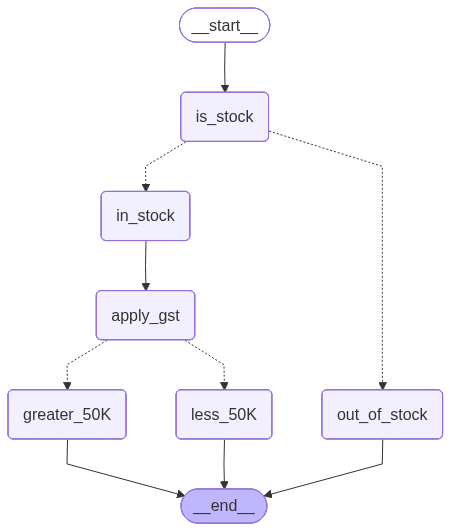

In [7]:
graph = StateGraph(OrderState)


graph.add_node("is_stock" , check_have_stock)
graph.add_node("out_of_stock" , out_of_stock)
graph.add_node("in_stock" , in_stock)
graph.add_node("apply_gst" , apply_gst)
graph.add_node("greater_50K" , greater_50K)
graph.add_node("less_50K" , less_50K)

graph.add_edge(START , "is_stock")
graph.add_conditional_edges("is_stock" , conditional_edge1)
graph.add_edge("out_of_stock" , END)
graph.add_edge("in_stock" , "apply_gst")
graph.add_conditional_edges("apply_gst" ,  conditional_edge2)
graph.add_edge("greater_50K" , END)
graph.add_edge("less_50K" , END)

chekcpointer = MemorySaver()


workflow = graph.compile(checkpointer=chekcpointer)
workflow


In [26]:
initial_state = { 
    "data": {"mangoes": [100, 1000]}, 
    "user_order": "mangoes",
    "total_items": 60,
    "messages": []
}

config = {"configurable": {"thread_id": 'thread-9'}}


In [27]:
# This will run until it hits 'interrupt' inside greater_50K
for event in workflow.stream(initial_state, config, stream_mode="values"):
    print(f"Current State Node: {event.get('messages')[-1].content if event.get('messages') else 'Start'}")


Current State Node: Start
Current State Node: Start
Current State Node: Start
Current State Node: Start
--- Entering Human-in-the-Loop Verification ---
Current State Node: Start


In [28]:
# Simulate human input
human_approval = "no" 

# Resume the workflow
# We pass None as the state because we are resuming from a checkpoint
for event in workflow.stream(Command(resume=human_approval), config, stream_mode="values"):
    if event.get("messages"):
        print("Update:", event["messages"][-1].content)


--- Entering Human-in-the-Loop Verification ---
Manual rejection received.
Update: Order rejected by admin.


In [29]:
config = {"configurable": {"thread_id": 'thread-0'}}


In [30]:
# This will run until it hits 'interrupt' inside greater_50K
for event in workflow.stream(initial_state, config, stream_mode="values"):
    print(f"Current State Node: {event.get('messages')[-1].content if event.get('messages') else 'Start'}")


Current State Node: Start
Current State Node: Start
Current State Node: Start
Current State Node: Start
--- Entering Human-in-the-Loop Verification ---
Current State Node: Start


In [31]:
# Simulate human input
human_approval = "yes" 

# Resume the workflow
# We pass None as the state because we are resuming from a checkpoint
for event in workflow.stream(Command(resume=human_approval), config, stream_mode="values"):
    if event.get("messages"):
        print("Update:", event["messages"][-1].content)


--- Entering Human-in-the-Loop Verification ---
Manual approval received.
Update: Order manually approved.
You buy mangoes with quantity : 60
 amount with out tax apllied : 60000 Pay total amount after tax : 70800.0
Thanks for shopping. Visit Again!
